# VGG-16 CNN Architecture

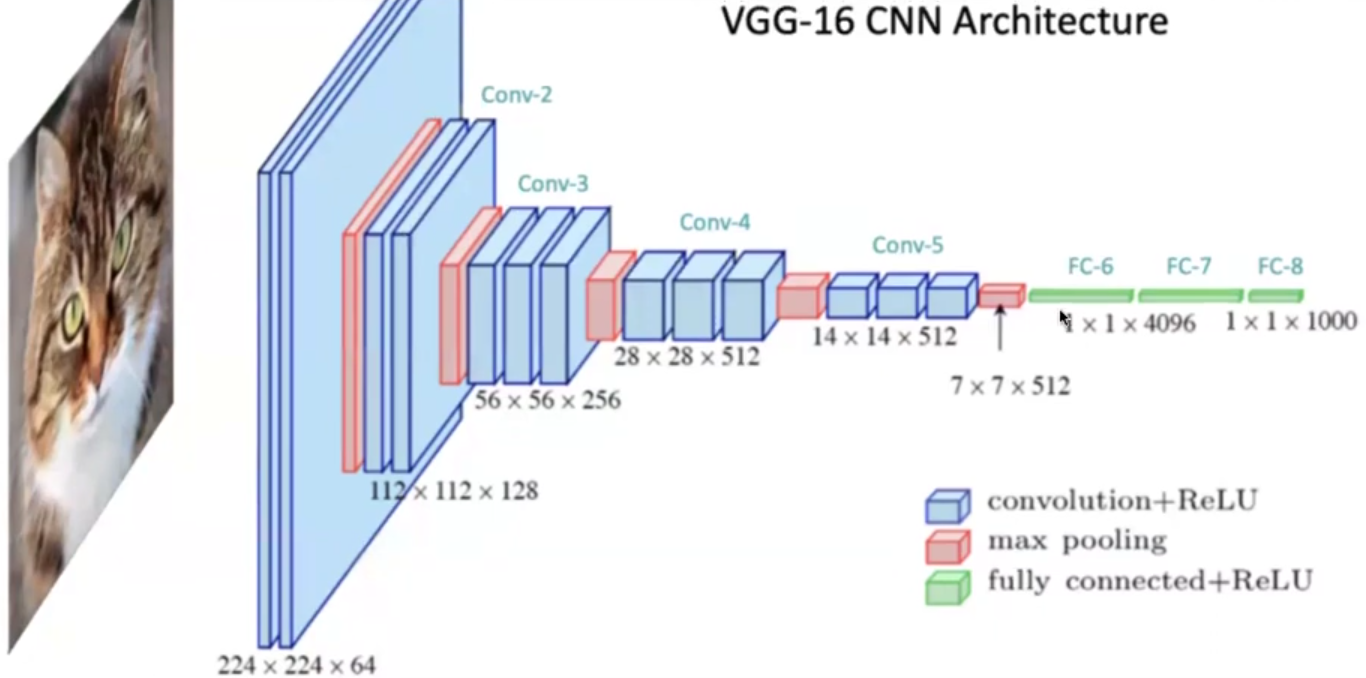


In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import time
import keras

from tensorflow.keras import layers, models
from tensorflow.keras.utils import plot_model
# Create a simple CNN model
from keras import layers
from keras import models


#


# Load MNIST dataset
mnist = tf.keras.datasets.mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

2026-03-22 21:19:43.506929: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-22 21:19:43.535400: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-22 21:19:44.265571: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
train_images.shape

(60000, 28, 28)

In [3]:
train_images

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [4]:
train_labels.shape

(60000,)

In [5]:
train_labels 

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [6]:
test_images.shape

(10000, 28, 28)

In [7]:
test_labels.shape

(10000,)

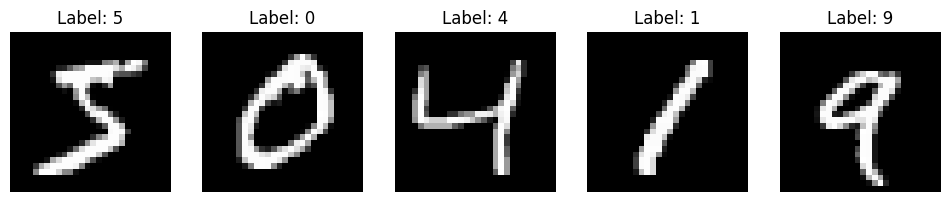

In [8]:
# Display a few sample images
num_samples = 5
plt.figure(figsize=(12,4))

for i in range(num_samples):
    plt.subplot(1, num_samples, i+1)
    plt.imshow(train_images[i], cmap='gray')
    plt.title(f"Label: {train_labels[i]}")
    plt.axis('off')

plt.show()

In [9]:
import numpy as num_samples
np.set_printoptions(edgeitems=30, linewidth=100000, 
                    formatter=dict(float=lambda x: "%.3g"%x))


print(train_images[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 182 247 241   0   

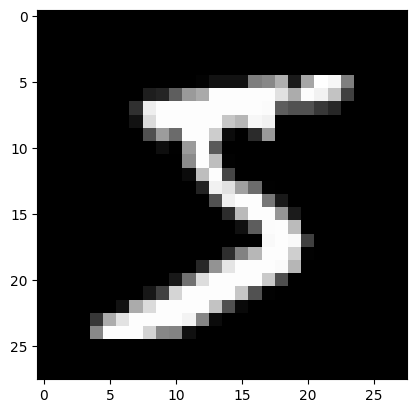

In [10]:
plt.imshow(train_images[0], cmap='gray')

In [11]:
from keras import layers
from keras import models

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation = 'relu', input_shape=(28, 28, 1)),

    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),

    layers.Dense(10, activation='softmax')
])

model.summary()

/home/serhii/Documents/DataScience/DSLectures/DataScience_sandbox/.ds_lect_env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-22 21:19:45.334249: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

# Convolutions

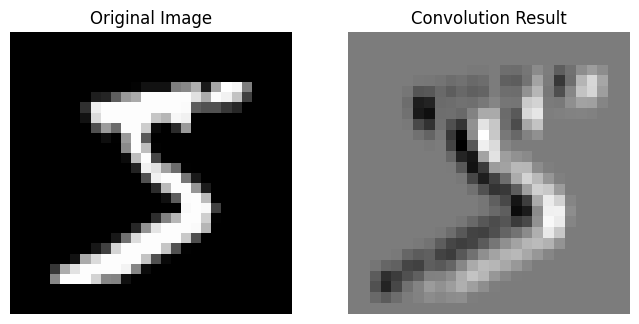

In [12]:
# layers.Conv 2D
def conv2d(image, kernel): # kernel = filters
    # Extract dimensions
    image_height, image_width = image.shape
    kernel_height, kernel_width = kernel.shape


    # Calculate output dimensions
    output_height = image_height - kernel_height + 1
    output_width = image_width - kernel_width + 1

    # Initialize the output with zeros
    output = np.zeros((output_height, output_width))

    # Perform the convolution
    for i in range(output_height):
        for j in range(output_width):
            # Extract the region of the image that corresponds to the convolution window
            image_patch = image[i: i + kernel_height, j:j + kernel_width]

            # Element-wise multiplication and summation
            output[i, j] = np.sum(image_patch * kernel)

    return output

# Load a sample image - "5"
image = train_images[0]


# Define a simple convolutional filter (Sobel edge detection filter)
# https://uk.wikipedia.org/wiki/Оператор_Собеля
sobel_filter = np.array([[1, 0, -1],
                         [2, 0, -2],
                         [1, 0, -1]])

# Normalize the filter to ensure it doesn't affect the scale of the gradients
sobel_filter = sobel_filter / 4.0

# Apply the convolation
result = conv2d(image, sobel_filter) 

# Plot the original image and the convolution result
plt.figure(figsize=(8,4))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(result, cmap='gray')
plt.title("Convolution Result")
plt.axis('off')

plt.show()


In [13]:
# Reminder
"""
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation = "relu", input_shape=(28, 28, 1))
    # num_params: kernel_dim*n_neurons + n_bias = (3+3)*32 + 32 = 9*32 + 32 = 288 + 32 = 320
    # output: image_length - kernel_length + 1, image_width - kernel_width + 1, n_neurons
    ])
"""
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

# Max Pooling

tf.Tensor([28 28  1], shape=(3,), dtype=int32)


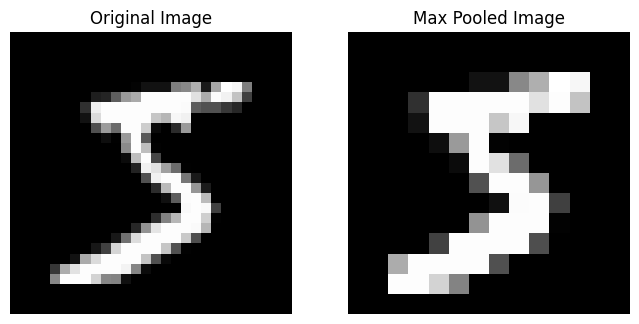

In [14]:
image = np.expand_dims(image, axis=-1) # Add channel dimension

# Define max pooling function
def max_pooling_2d(input_tensor, pool_size):
    input_shape = tf.shape(input_tensor)
    print(input_shape)
    input_height, input_width, num_channels  = input_shape[0], input_shape[1], input_shape[2]

    output_height = input_height // pool_size
    output_width = input_width // pool_size

    # Reshape the input tensor to prepare for max pooling
    reshaped_input = tf.reshape(input_tensor, [output_height, pool_size, output_width, pool_size, num_channels])
    input_shape_after_reshaping = tf.shape(reshaped_input)

    # Take the max along the pooling window dimensions
    pooled_tensor = tf.math.reduce_max(reshaped_input, axis=[1,3])

    return pooled_tensor

# Perform max pooling with a pool size of 2x2
pool_size = 2
pooled_image = max_pooling_2d(image, pool_size)

# Plot the original and pooled images
plt.figure(figsize=(8, 4))

plt.subplot(1,2,1)
plt.imshow(np.squeeze(image), cmap='gray')
plt.title('Original Image')
plt.axis('off')


plt.subplot(1,2,2)
plt.imshow(np.squeeze(pooled_image), cmap='gray')
plt.title('Max Pooled Image')
plt.axis('off')

plt.show()



In [15]:
#print(pooled_image)
print(tf.transpose(pooled_image))

2026-03-22 21:19:45.526948: E tensorflow/core/util/util.cc:131] oneDNN supports DT_UINT8 only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


tf.Tensor(
[[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0]
  [  0   0   0   0   0   0   0   0   0   0   0   0   0   0]
  [  0   0   0   0   0   0   0   0   0   0   0 172 253   0]
  [  0   0   0  49  18   0   0   0   0   0   0 253 253   0]
  [  0   0   0 253 253  14   0   0   0   0  66 253 212   0]
  [  0   0   0 253 253 154  11   0   0   0 253 253 132   0]
  [  0   0  18 253 253 253 253  81   0 148 253 253   0   0]
  [  0   0  18 253 198   2 225 253  16 253 253  80   0   0]
  [  0   0 136 253 247   0 108 253 252 253 253   0   0   0]
  [  0   0 175 225   0   0   0 150 253 253  78   0   0   0]
  [  0   0 255 253   0   0   0   0  64   2   0   0   0   0]
  [  0   0 247 195   0   0   0   0   0   0   0   0   0   0]
  [  0   0   0   0   0   0   0   0   0   0   0   0   0   0]
  [  0   0   0   0   0   0   0   0   0   0   0   0   0   0]]], shape=(1, 14, 14), dtype=uint8)


In [16]:
print(tf.transpose(image))

tf.Tensor(
[[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
  [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
  [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
  [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
  [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  55 136   0   0   0]
  [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 172 253   0   0   0]
  [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  18 226 253   0   0   0]
  [  0   0   0   0   0   0   0  49  18   0   0   0   0   0   0   0   0   0   0   0   0   0 171 253 253   0   0   0]
  [  0   0   0   0   0   0  30 238 219  80   0   0   0   0   

In [17]:
tf.shape(pooled_image)

<tf.Tensor: shape=(3,), dtype=int32, numpy=array([14, 14,  1], dtype=int32)>

In [18]:
pooled_image[:, :, 0]

<tf.Tensor: shape=(14, 14), dtype=uint8, numpy=
array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,  18,  18, 136, 175, 255, 247,   0,   0],
       [  0,   0,   0,  49, 253, 253, 253, 253, 253, 225, 253, 195,   0,   0],
       [  0,   0,   0,  18, 253, 253, 253, 198, 247,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,  14, 154, 253,   2,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,  11, 253, 225, 108,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,  81, 253, 253, 150,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  16, 252, 253,  64,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0, 148, 253, 253, 253,   2,   0,   0,   0],
       [  0,   0,   0,   0,  66, 253, 253, 253, 253,  78,   0,   0,   0,   0],
       [  0,   0, 172, 253, 253, 253, 253,  80,   0,   0,   0,   0,   0,   0],
    

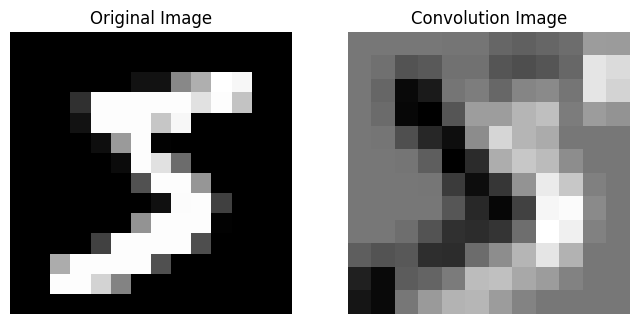

In [19]:
# Another convolutional layer
result_2 = conv2d(pooled_image[:, :, 0].numpy(), sobel_filter)

# Plot the original image and convolution
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(np.squeeze(pooled_image[:, :, 0]), cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(np.squeeze(result_2), cmap='gray')
plt.title('Convolution Image')
plt.axis('off')

plt.show()

# Padding

Original Image Shape: (28, 28, 1)
Padded Image Shape: (36, 36, 1)


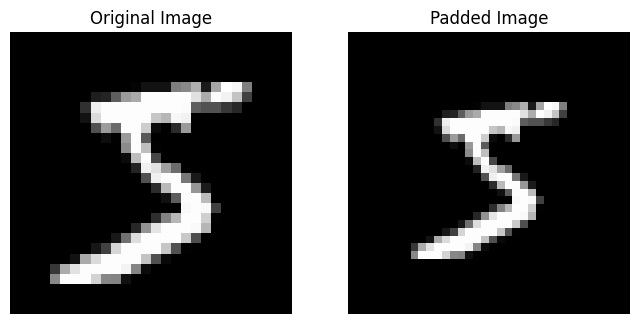

In [20]:
# Select the first example from the dataset
image = train_images[0]
image = np.expand_dims(image, axis=-1) # Add channel dimension

# Print the original image shape
print('Original Image Shape:', image.shape)

# Define the amount of padding for each dimension
pad_height = 4
pad_width = 4

# Pad the image using tf.pad
padded_image = tf.pad(image, paddings=[[pad_height, pad_height], [pad_width, pad_width], [0,0]])

# Print the padded image shape
print("Padded Image Shape:", padded_image.shape)

# Plot the original and padded images
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(np.squeeze(image), cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(np.squeeze(padded_image), cmap='gray')
plt.title('Padded Image')
plt.axis('off')


plt.show()


In [21]:
[[pad_height, pad_height], [pad_width, pad_width], [0, 0]] # paddings

[[4, 4], [4, 4], [0, 0]]

# Padding and Striding

In [22]:
model_padded = models.Sequential([
    layers.Conv2D(32, (3,3), strides=(1,1), padding='same', activation='relu', input_shape=(28, 28, 1)),
    
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), strides=(1,1), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), strides=(1,1), padding='same', activation='relu'),

    layers.Flatten(),
    layers.Dense(10, activation='softmax')

])

model_padded.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        31,370 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 87,114 (340.29 KB)

 Trainable params: 87,114 (340.29 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# Without padding
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

# Flatting

Original Image Shape: (28, 28, 1)
Flattened Image Shape: (784,)


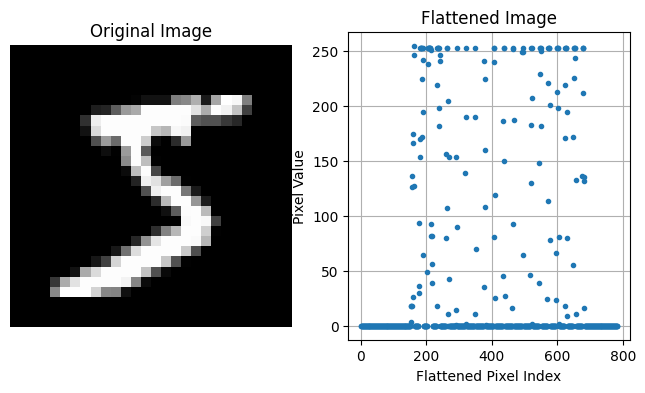

In [24]:
# Select the first example from the dataset
image = train_images[0]
image = np.expand_dims(image, axis=-1) # Add channel dimension

# Print the original iamge shape
print("Original Image Shape:", image.shape)

# Flatten the image using tf.reshape
flattened_image = tf.reshape(image, shape=(-1,))

# Print the flattened image shape
print("Flattened Image Shape:", flattened_image.shape)

# Plot the original and flattened images
plt.figure(figsize=(8, 4))

plt.subplot(1,2,1)
plt.imshow(np.squeeze(image), cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.plot(flattened_image.numpy(), marker = '.', linestyle="None")
plt.title("Flattened Image")
plt.xlabel('Flattened Pixel Index')
plt.ylabel('Pixel Value')
plt.grid(True)

plt.show()

In [25]:
flattened_image.numpy()

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 170, 253, 253, 253, 253, 253, 225, 172, 253, 242, 195,  64,   0,   0,   0,   0,   0,   0,   0

# Train the final model

Epoch 1/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9567 - loss: 0.1404 - val_accuracy: 0.9863 - val_loss: 0.0413
Epoch 2/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9858 - loss: 0.0466 - val_accuracy: 0.9857 - val_loss: 0.0450
Epoch 3/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9901 - loss: 0.0330 - val_accuracy: 0.9872 - val_loss: 0.0403
Epoch 4/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9924 - loss: 0.0248 - val_accuracy: 0.9901 - val_loss: 0.0324
Epoch 5/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9935 - loss: 0.0201 - val_accuracy: 0.9896 - val_loss: 0.0345
Epoch 6/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9944 - loss: 0.0168 - val_accuracy: 0.9916 - val_loss: 0.0315
This took 67.86500358581543 seconds to run.


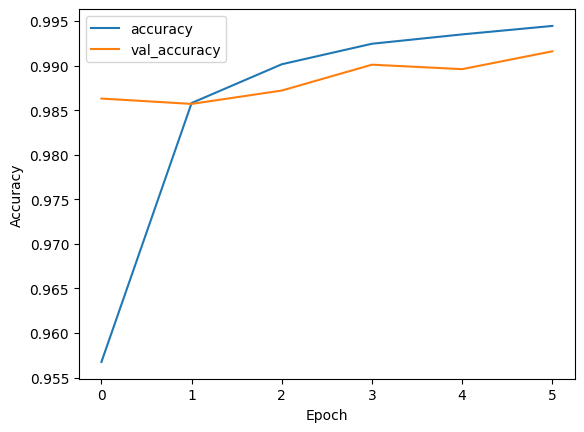

In [26]:
# Load a dataset (e.g., CIFAR-10 for simplicity)
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# Preprocess the data
train_images, test_images = train_images /  255.0, test_images / 255.0

# Create a smiple CNN model
#from keras import layers
#from keras import models

# TODO compare CPU and GPU

time_start = time.time()

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Visualize the model architecture
plot_model(model, to_file='cnn_model.png', show_shapes=True, show_layer_names=True)


# Train the model
history = model.fit(train_images, train_labels, epochs=6, validation_data=(test_images, test_labels))
time_end = time.time()

print(f"This took {time_end-time_start} seconds to run.")

# Visualize the traing process
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [27]:
test_loss, test_accuracy = model.evaluate(test_images, test_labels)
print(f"Test Accuracy: {test_accuracy}")

  1/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 1.0000 - loss: 2.4051e-04

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9916 - loss: 0.0315
Test Accuracy: 0.991599977016449


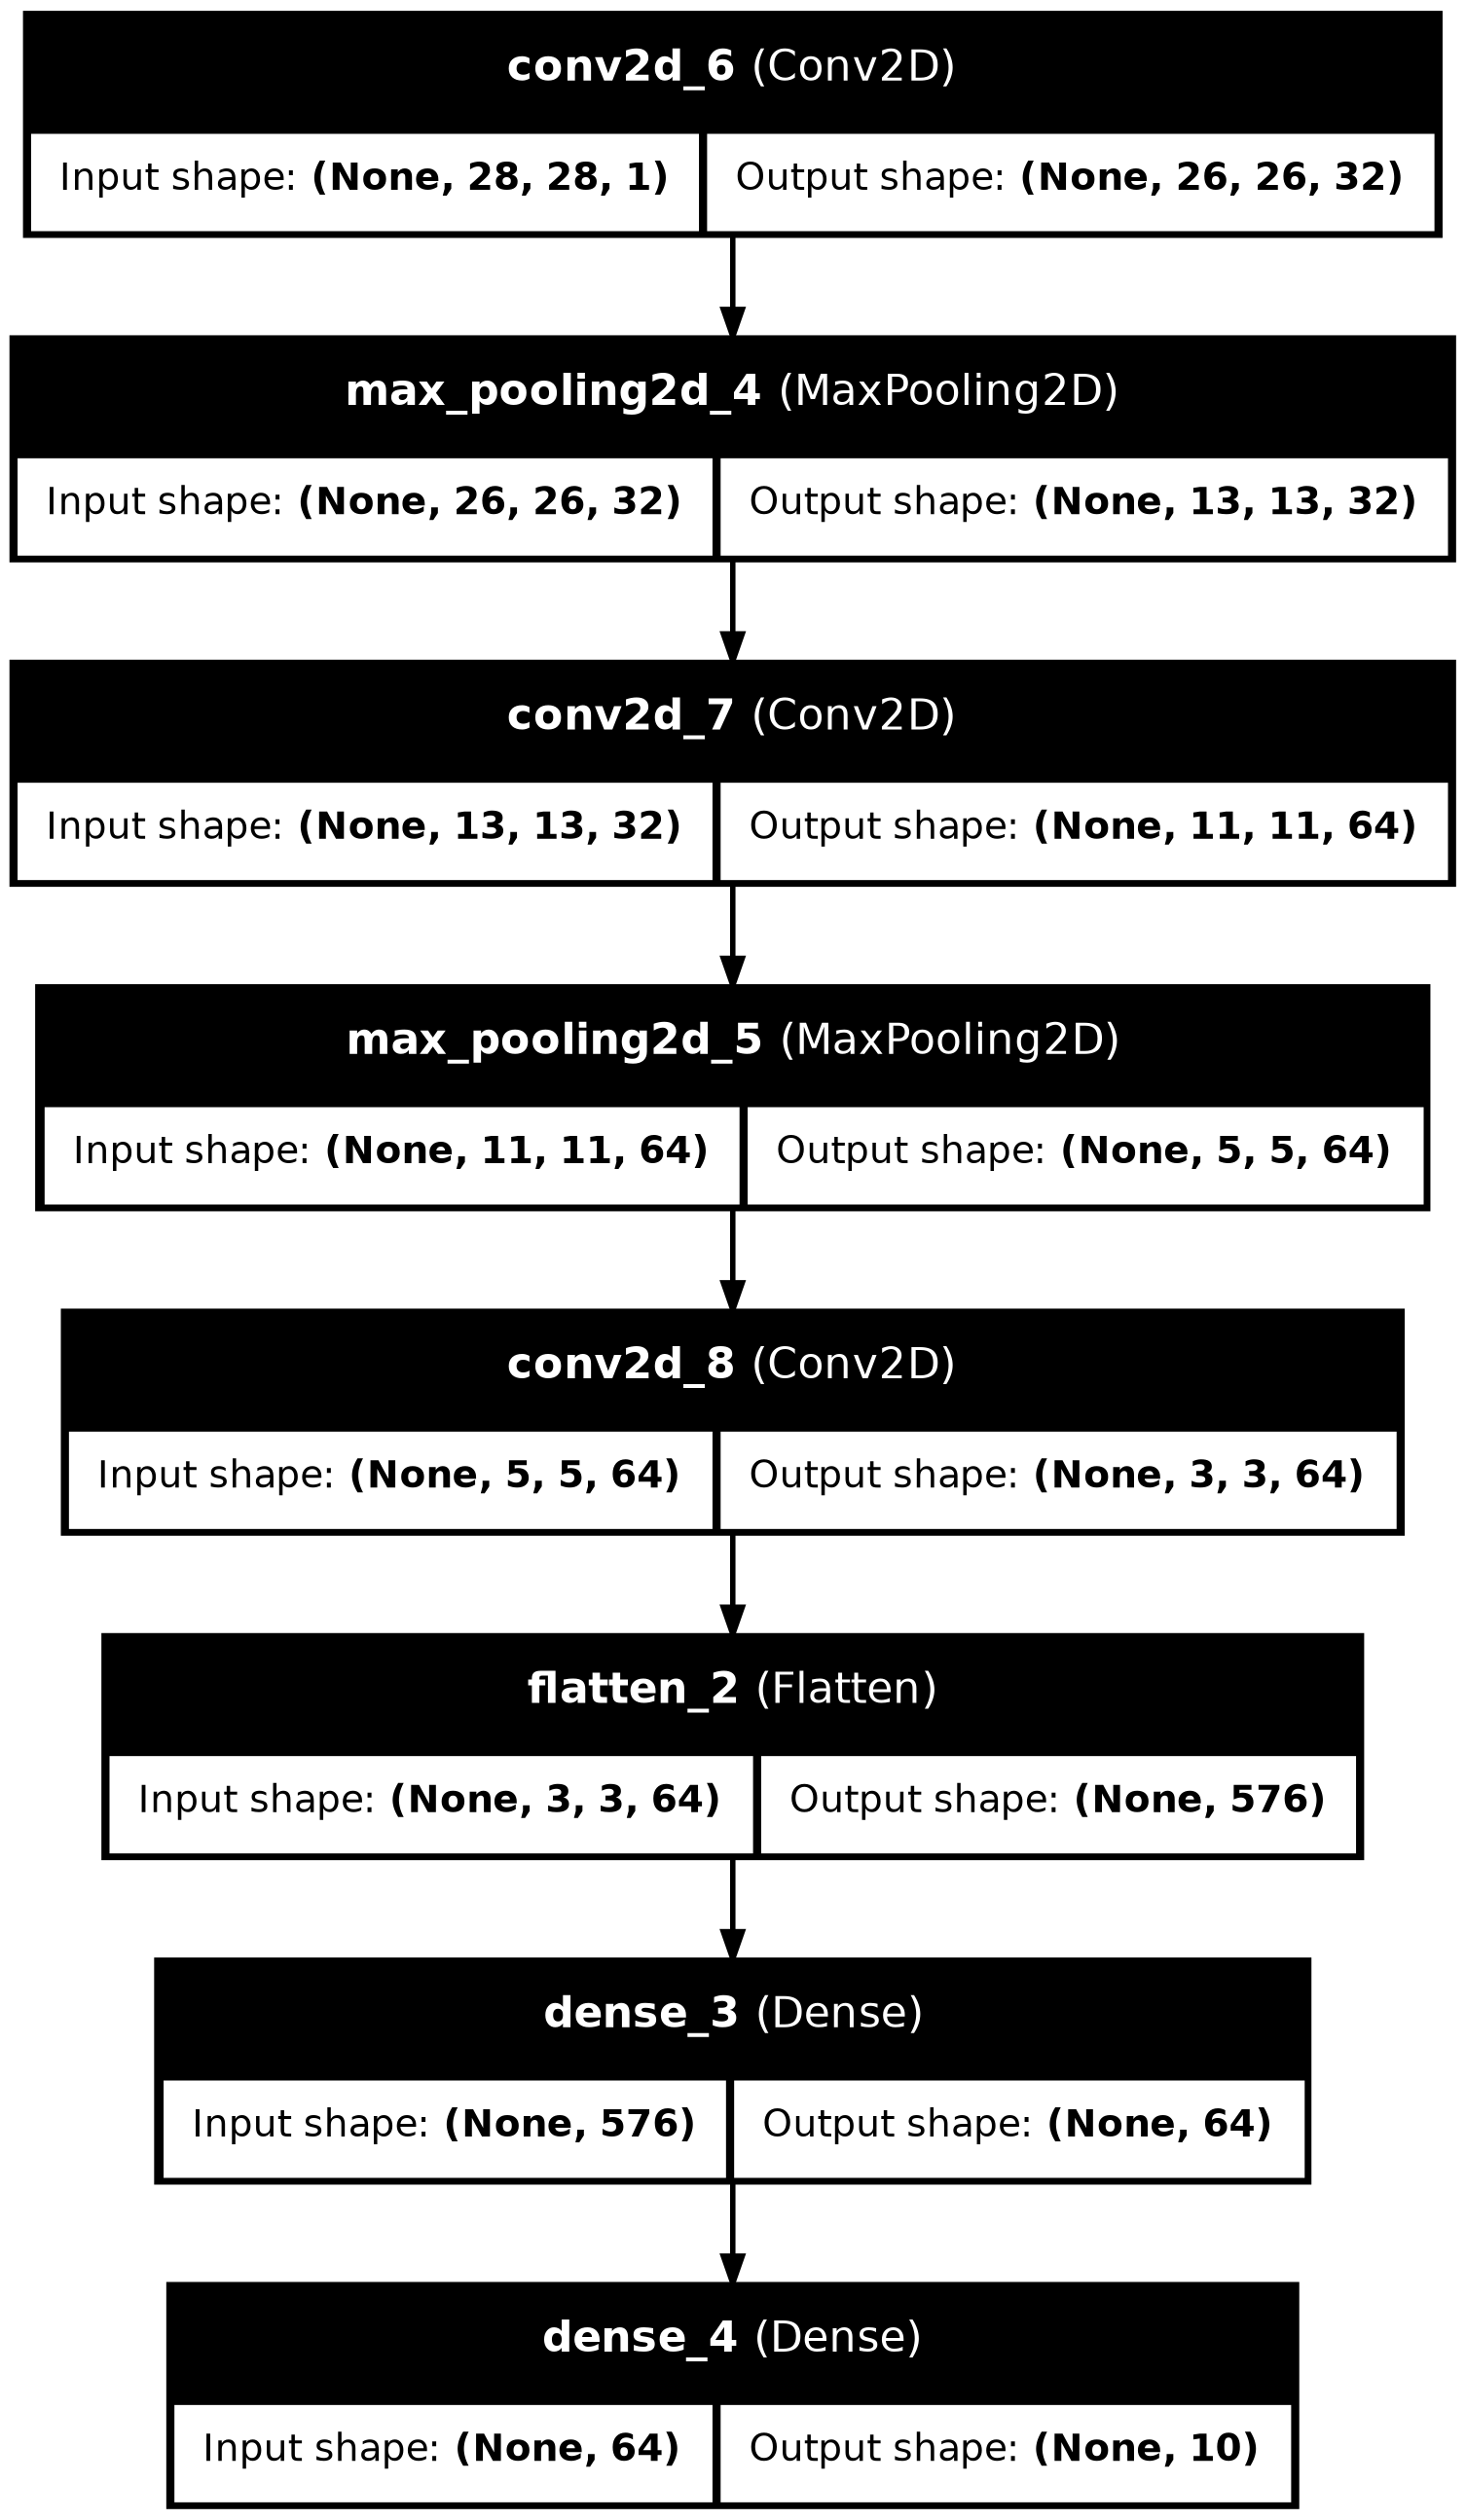

In [28]:
plot_model(model, to_file='cnn_model.png', show_shapes=True, show_layer_names=True)

In [29]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 279,968 (1.07 MB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 186,646 (729.09 KB)

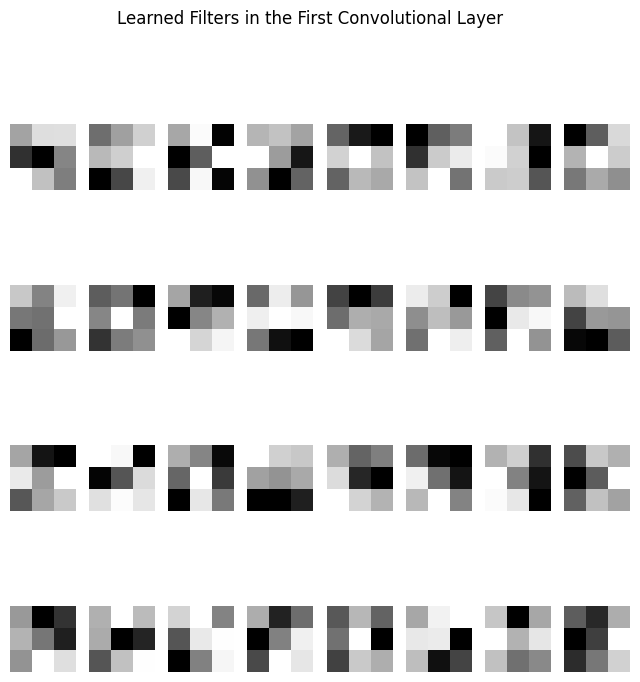

In [ ]:
# Extract the filters from the first convolutional layer
filters = model.layers[0].get_weights()[0]

# Visualize the learned filters
# Learned Filters:
# The first part of the code visualizes the learned filters from the first convolutional layer. Each filter is a small matrix
# of wights that slides over the input image, cpturing different features.

plt.figure(figsize=(8,8))
for i in range(32):
    plt.subplot(4, 8, i+1)
    plt.imshow(filters[:,:,0,i], cmap='gray')
    plt.axis('off')
plt.suptitle('Learned Filters in the First Convolutional Layer')
plt.show()

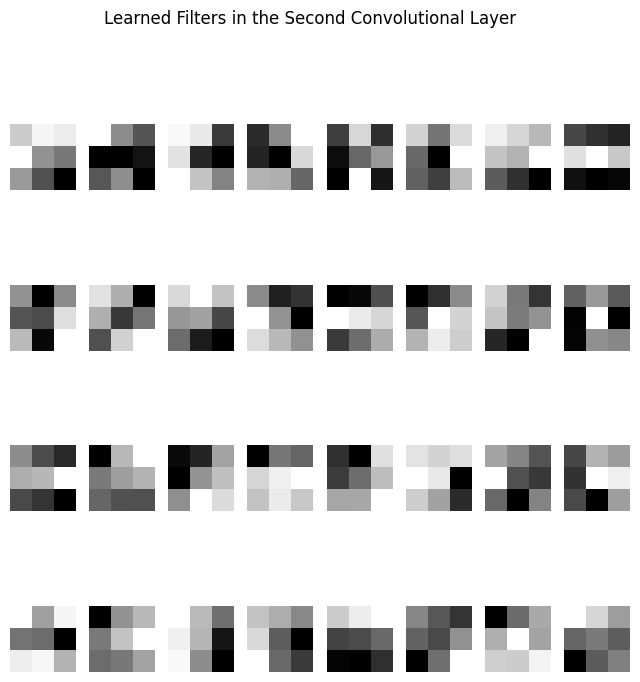

In [32]:
# Extract the filters from the second convolutional layer
filters_2 = model.layers[2].get_weights()[0]

# Visualize the learned filters
# Learned Filters:
# The first part of the code visualizes the learned filters from the first convolutional layer. Each filter is  a small matrix
# of wights that slides over the input image, capturing different features.


plt.figure(figsize=(8,8))
for i in range(32):
    plt.subplot(4, 8, i+1)
    plt.imshow(filters_2[:,:,0,i], cmap='gray')
    plt.axis('off')
plt.suptitle('Learned Filters in the Second Convolutional Layer')
plt.show()
